# Fluorescence Correlation Spectroscopy

Fluorescence Correlation Spectroscopy has been both a technique, and analysis tool.

FCS analyzes the fluctuations in signal intensity over time.
These fluctuations are the result of a number of processes.

These can be thought of in 2 broad categories:
1. Diffusion
2. Fluorophore/Molecule intrinsic fluctuations

See the many references to find the relevant equations for fitting the curves to diffusion times, triplet state etc.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import smfbursts as smf
import smfbursts.fcs as fcs

raw = smf.photonHDF5.load('data/HP3_TE300_SPC630.hdf5')
data = smf.photonHDF5.regularize_dets(raw)

## Correlation

Both auto and cross correlation can be computed with the `fcs.correlate()` function.
Simply supply it with the data object, and which stream(s) to correlate.
It is also recomended to include the bins argument to define the time range and spacing with which to compute the correlation.

Note that under the hood, this uses a C-implemntation of [Laurence 2006](https://doi.org/10.1364/OL.31.000829).

The signature of the function is

```python
corrl, bins = fcs.correlate(data, streamT=smf.PhSel('all'), streamU=None, bins=None)
```

If `streamU` is not specified, it will compute the auto-correlation, if both `streamT` and `streamU` are specified, the cross-correlation is computed.

It should also be understood that the correlation of $A x B$ is different from $B x A$, but typically the differences are minimal.
This is because streamT serves as the "start" times of the correlation, while streamU as the "stop" times.

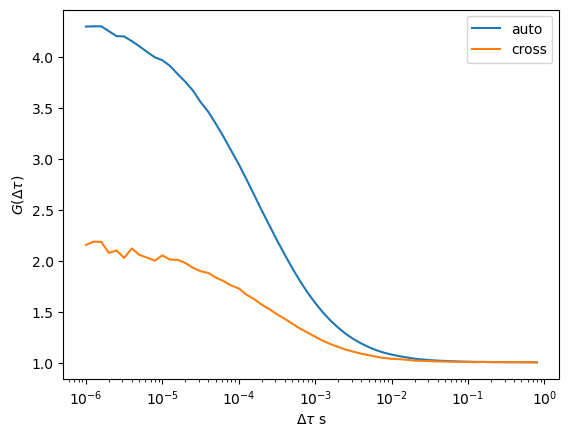

In [2]:
auto, bins = fcs.correlate(data, smf.PhSel('0ex'), bins=np.logspace(-6,0,61))
cross, bins = fcs.correlate(data, smf.PhSel('0ex0em'), smf.PhSel('0ex1em'), bins=np.logspace(-6,0,61))

# plot the correlations
plt.semilogx(bins[:-1],auto, label='auto')
plt.semilogx(bins[:-1],cross, label='cross')
plt.xlabel(r'$\Delta\tau$ s')
plt.ylabel(r'$G(\Delta\tau)$')
plt.legend()

## Purified FCS

In [Laurence 2007](https://doi.org/10.1529/biophysj.106.093591), a modification to the equations
was introduced allowing for correlation only of bursts, basically a way to join many short time segments into a single correlation calcualtion.

This uses the `fcs.purified_fcs()` function.

As this functon's second argument, it requires a `Param` defining the time ranges to correlate, 
typically a `Bursts` or `BurstOvlp` based `Param`, but it can be any `BasePhotonTable` based `Param`.

This function has 3 additional keyword arguments:
- "expand": the time (in seconds) around bursts to expand the time ranges of correlation. **Note** the "bins" should not exceed times longer than expand.
- "fuse": Minimum separation between time ranges to fuse, this uses the same function as the "fuse" parameter of `Bursts` and `BurstOvlp` tables.
- "gate": The gate to apply to "bursts", this argument works in conjuction with "bursts" as the "gate" argument works in other parts of smfBursts.

In [3]:
bg = smf.fretfactory.make_bg(data)
brst = smf.fretfactory.make_burst_search(bg['bg'], m=10, F=6.0, streams=(smf.PhSel('0ex'), smf.PhSel('1ex1em')))
gate = smf.make_geq_gate(brst['NphDex_bg'], 60.0)

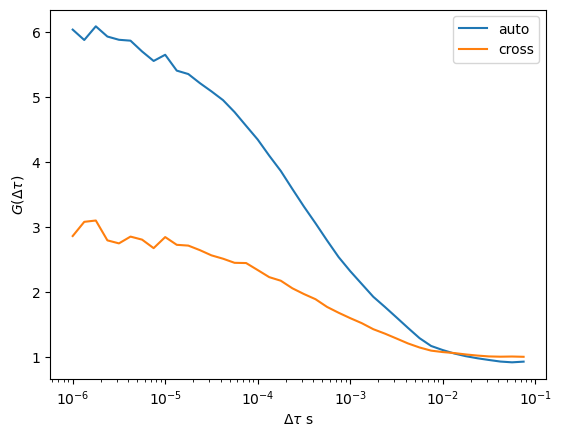

In [4]:
auto, bins = fcs.purified_fcs(data, brst['bursts'], gate=gate,
                              streamT=smf.PhSel('0ex'), 
                              bins=np.logspace(-6,-1,41))

cross, bins = fcs.purified_fcs(data, brst['bursts'], gate=gate,
                               streamT=smf.PhSel('0ex0em'), streamU=smf.PhSel('0ex1em'), 
                               bins=np.logspace(-6,-1,41), expand=0.3)

# plot the correlations
plt.semilogx(bins[:-1],auto, label='auto')
plt.semilogx(bins[:-1],cross, label='cross')
plt.xlabel(r'$\Delta\tau$ s')
plt.ylabel(r'$G(\Delta\tau)$')
plt.legend()

## Filtered FCS (FLCS)

Finally, the nanotimes of the data can be incorporated using a weights array to get correlation of "species" with different fluoresence lifetiems.
This method has been variously calld filterd FCS, and Fluoresence Lifetimes Correlation Spectroscoy (FLCS). 
[Bohmer 2002](https://doi.org/10.1016/S0009-2614(02)00044-1)

This can also be combined with purified fcs.

A good review:
[Ghosh 2018](https://doi.org/10.1016/j.ymeth.2018.02.009)

The `fcs.flcs()` handles this, find it's documentation under the Documentation/Fluoresence Correlation Spectroscopy section.

This implementation is still experimental.
Finding the correct filters is a process of trial and error, and I have yet to find an adequate test dataset.